# **Mini-Lab:** Wireless Networks 

- Student 1
- Student 2

## Objective
Analyze how wireless network performance changes under different conditions (WiFi vs Mobile Data).

You will measure:
- Latency
- Stability (variance)
- Jitter

Then, you will relate your results to networking concepts such as SNR, interference, and mobility.

## Instructions

1. Connect to WiFi and run the measurements
2. Activate mobile hotspot (or connect to mobile data) and repeat
3. Compare results

Work in pairs if needed.

In [ ]:
# Import required libraries
import subprocess # Allows running system commands like ping
import re # Used to extract numbers from text using patterns
import numpy as np # Used for numerical calculations
import matplotlib.pyplot as plt # Used for plotting graphs


## **Step 1:** Run Ping Test

We will send packets to Google's DNS server (8.8.8.8) to measure latency.

In [ ]:
# Define a function to run ping
def run_ping(host="8.8.8.8", count=10): # Default host is Google's public DNS server, almost always reachable.
    # Run the ping command in the system terminal
    result = subprocess.run(["ping", "-c", str(count), host], capture_output=True, text=True) # -c specifies the number of pings, capture_output captures the output, text=True returns it as a string
    # Return the full output as text
    return result.stdout # stdout contains the standard output of the command

# Execute ping
ping_output = run_ping()

# Print the raw output
print(ping_output)

PING 8.8.8.8 (8.8.8.8): 56 data bytes
64 bytes from 8.8.8.8: icmp_seq=0 ttl=113 time=76.474 ms
64 bytes from 8.8.8.8: icmp_seq=1 ttl=113 time=109.478 ms
64 bytes from 8.8.8.8: icmp_seq=2 ttl=113 time=153.775 ms
64 bytes from 8.8.8.8: icmp_seq=3 ttl=113 time=122.342 ms
64 bytes from 8.8.8.8: icmp_seq=4 ttl=113 time=75.844 ms
64 bytes from 8.8.8.8: icmp_seq=5 ttl=113 time=88.762 ms
64 bytes from 8.8.8.8: icmp_seq=6 ttl=113 time=137.449 ms
64 bytes from 8.8.8.8: icmp_seq=7 ttl=113 time=105.239 ms
64 bytes from 8.8.8.8: icmp_seq=8 ttl=113 time=151.394 ms
64 bytes from 8.8.8.8: icmp_seq=9 ttl=113 time=75.971 ms

--- 8.8.8.8 ping statistics ---
10 packets transmitted, 10 packets received, 0.0% packet loss
round-trip min/avg/max/stddev = 75.844/109.673/153.775/29.081 ms



## **Step 2:** Extract Latency Values

We extract each response time from the ping output.

In [ ]:
# Function to extract latency values from ping output
def extract_latencies(ping_text):
    # Regular expression to find time values (e.g., time=23.4 ms)
    # It searches for patterns like "time=23.4" and extracts only the numeric part (23.4).
    # The result is a list of strings representing latency values.
    times = re.findall(r'time=([\d\.]+)', ping_text) # r indicates a raw string, time= is the literal text to match, \d matches digits, \. matches the decimal point, and + means one or more occurrences. The parentheses capture the numeric part for extraction.
    
    # Convert extracted values to float numbers
    return [float(t) for t in times]

# Extract latencies
latencies = extract_latencies(ping_output)

# Print the list of latencies
print(latencies)

[76.474, 109.478, 153.775, 122.342, 75.844, 88.762, 137.449, 105.239, 151.394, 75.971]


## **Step 3:** Compute Metrics

We compute:
- Average latency
- Standard deviation (stability)
- Jitter (variation between consecutive packets)

In [4]:
# Convert latencies to numpy array for easier computation
lat_array = np.array(latencies)

# Compute average latency
avg_latency = np.mean(lat_array)

# Compute standard deviation (measure of stability)
std_latency = np.std(lat_array)

# Compute jitter (mean of absolute differences between consecutive values)
jitter = np.mean(np.abs(np.diff(lat_array)))

# Print results
print("Average Latency:", avg_latency, "ms")
print("Stability (Std Dev):", std_latency)
print("Jitter:", jitter)

Average Latency: 109.67280000000001 ms
Stability (Std Dev): 29.0809317759937
Jitter: 41.180555555555564


## **Step 4:** Plot Results

Visualize latency over time.

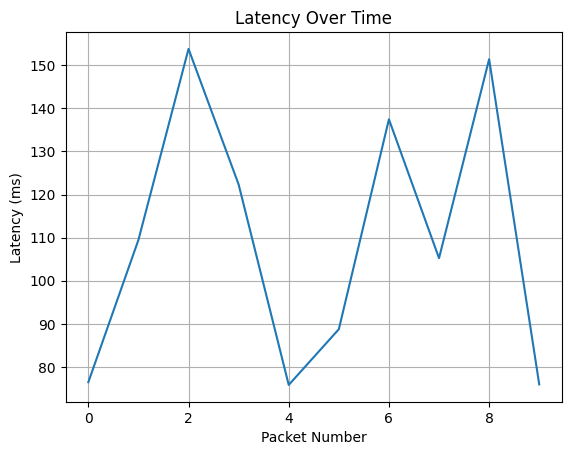

In [5]:
# Create a plot of latency values
plt.plot(lat_array)

# Label axes
plt.xlabel("Packet Number")
plt.ylabel("Latency (ms)")

# Title of the plot
plt.title("Latency Over Time")

# Show grid for better readability
plt.grid()

# Display the plot
plt.show()

## **Step 5:** Repeat with Mobile Data

Now switch to:
- Mobile hotspot OR
- Cellular data

Repeat all previous steps and record results.

## Analysis Questions

Answer the following:

**1. Which network had lower latency? Why?**  
Insert your answer here..  

**2. Which network was more stable (lower standard deviation)?**  
Insert your answer here..  

**3. Which network had higher jitter?**  
Insert your answer here..  

**4. How do your results relate to interference and signal strength?**  
Insert your answer here..  

**5. Why might mobile networks behave differently than WiFi?**  
Insert your answer here..  

**6. How does this relate to SNR and BER?**  
Insert your answer here..  

**7. Why could TCP misinterpret wireless losses as congestion?**  
Insert your answer here..  

## Bonus: Simulated SNR vs Distance

In [ ]:
# Generate distance values
distance = np.linspace(1, 20, 50)

# Simulate SNR decreasing with distance (inverse square law)
snr = 1 / (distance**2)

# Plot SNR vs distance
plt.plot(distance, snr)
plt.xlabel("Distance")
plt.ylabel("SNR (simulated)")
plt.title("SNR vs Distance")
plt.grid()
plt.show()

## **Evaluation Rubric**

| Criteria | Points |
|---------|--------|
| Code execution (runs correctly) | 2 |
| Data collection (WiFi + Mobile) | 2 |
| Correct metric computation | 2 |
| Plot and visualization | 2 |
| Answers and analysis quality | 2 |

Total: 10 points